# Integrating individual-level task data further improves parcellation

This jupyter notebook is to demenstrate a comparison whether the individual parcellations generated by fusing task and rest data at individual level can further improve the parcellation than using single modality.

In [3]:
import os, sys, warnings
sys.path.append(os.path.abspath('..'))
warnings.filterwarnings('ignore')

import time
import numpy as np
import torch as pt
import nibabel as nb
import nitools as nt
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import Functional_Fusion.atlas_map as am
import Functional_Fusion.dataset as ds
import HierarchBayesParcel.arrangements as ar
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
import FusionModel.util as futil
import FusionModel.evaluate as ev
import IndividualParcellation.utils as ut

from pathlib import Path
RES_DIR = '/data/tge/dzhi/Indiv_par/Evaluations'
# from global_config import MODEL_DIR, BASE_DIR, ATLAS_DIR, DEVICE
# from scripts.group_parcellation import build_ukb_datasets, convert_hard_to_prob, get_indiv_parcellation_from_model
# from scripts.indiv_eval import *

ERIS_DIR = '/home/dzhi/eris_mount'
if not Path(ERIS_DIR).exists():
    ERIS_DIR = '/data/tge'
if not Path(ERIS_DIR).exists():
    raise (NameError('Could not find hcp_dir'))

# 1. Experiments on HCP dataset, K=17

## Same group priors, 1run rest, or 1run rest + 1session task 
1 run rest = 15 mins, 1 session task = 23m17s, 7 x 1 run task domains.

### Integrating individual task and rest data for parcellation better than resting state data alone

### Fusion(MdNiIbHc) prior - HCP 1 run rs-data vs. 1run rs-data + 1session task-data


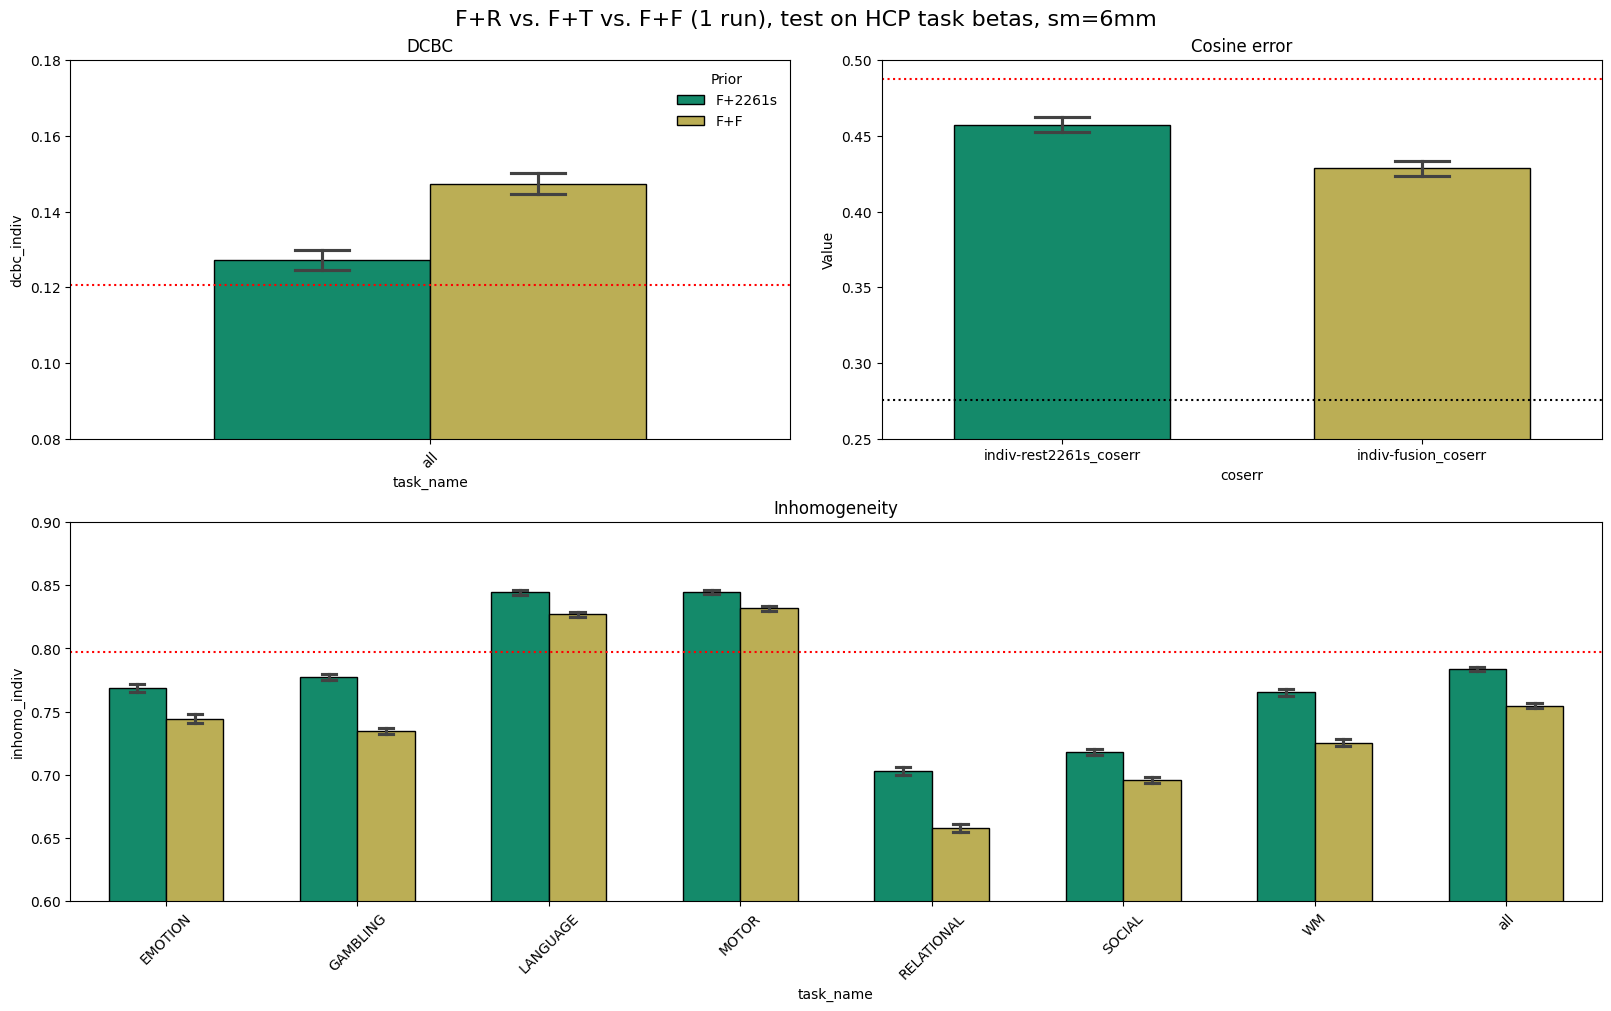

(3200,) (3200,) (3200,)
TtestResult(statistic=54.616334893299594, pvalue=9.634324579740925e-122, df=199)
TtestResult(statistic=54.47552137180646, pvalue=1.5596024488319556e-121, df=199)
TtestResult(statistic=-23.72077146759975, pvalue=6.557812424811752e-60, df=199)
TtestResult(statistic=-28.634948727576877, pvalue=1.670556511317001e-72, df=199)
TtestResult(statistic=38.29769430526531, pvalue=9.246052390278049e-94, df=199)


In [9]:
# ================= LOAD =================
HCP200_DIR = ERIS_DIR + "/dzhi/Indiv_par/Models/Models_03/indiv_parcellation/HCP200_test_set"

kong_indiv = pd.read_csv(
    "/home/dzhi/eris_mount/dzhi/Indiv_par/Results/section_2"
    "/eval_indiv-mRBM_MSHBM-HCP200_1-4run_K-17_test_on_HCPtask-beta_sm6.tsv",
    sep="\t"
)
kong_indiv = kong_indiv.loc[kong_indiv["train_sess"]=="run-4"]
kong_indiv["type"] = "MSHBM"

df_rest_1run = pd.read_csv(HCP200_DIR + "/eval_indiv-mRBM_HBP-HCP200_1run_K-17_test_on_HCPtask-beta_sm6.tsv", sep="\t")
df_rest_1run["type"] = "R+R"

df_fusion_2261s = pd.read_csv(HCP200_DIR + "/eval_indiv-mRBM_MdNiIbHc-HCP200_rest2261s_K-17_test_on_HCPtask-beta_sm6.tsv", sep="\t")
df_fusion_2261s["type"] = "F+2261s"

df_fusion_1run = pd.read_csv(HCP200_DIR + "/eval_indiv-mRBM_MdNiIbHc-HCP200_1run_K-17_test_on_HCPtask-beta_sm6.tsv", sep="\t")
df_fusion_1run["type"] = "F+R"

df_fusion_fusion_1run = pd.read_csv(HCP200_DIR + "/eval_indiv-mRBM_MdNiIbHc-HCP200_rest1run+task1run_K-17_test_on_HCPtask-beta_sm6.tsv", sep="\t")
df_fusion_fusion_1run["type"] = "F+F"

df_task_1run = pd.read_csv(HCP200_DIR + "/eval_indiv-mRBM_MdNiIbHc-HCP200_task1run_K-17_test_on_HCPtask-beta_sm6.tsv", sep="\t")
df_task_1run["type"] = "F+T"

results = pd.concat([kong_indiv,df_fusion_2261s,df_fusion_fusion_1run], ignore_index=True)

# ================= SUBJECT MEANS =================
subj_avg = (
    results
    .groupby(["subj_num","task_name","type"], as_index=False)
    .mean(numeric_only=True)
)

# ================= COSERR =================
df_coserr = pd.read_csv(
    HCP200_DIR + "/coserr_indiv-mRBM_MdNiIbHc-HCP200_rest_vs_fusion_K-17_test_on_HCPtask-beta_sm6.tsv",
    sep="\t"
)

df_long = df_coserr[['indiv-rest2261s_coserr','indiv-fusion_coserr']] \
            .melt(var_name="coserr", value_name="Value")

# ================= STYLING =================
type_order = ["F+2261s","F+F"]
palette = {
    "MSHBM": "#4477AA",
    "R+R": "#EE6677",
    "F+R": "#009E73",
    "F+2261s": "#009E73",
    "F+F": "#CCBB44",
    "F+T": "#AA3377"
}


# ========== styling ==========
BAR_WIDTH = 0.6          # smaller → gap between hue bars
EDGE_COLOR = "black"
EDGE_WIDTH = 1.0
CAPSIZE = 0.15

# 1. Define the spanning layout: Top row has 2 plots, Bottom row has 1 wide plot
layout = [
    ['dcbc', 'coserr'],
    ['inhomo', 'inhomo']
]

fig, axd = plt.subplot_mosaic(layout, figsize=(16, 10), constrained_layout=True)

# 2. Map the dictionary axes to a list to keep your axes[0], [1], [2] indexing
# Order: [Top Left, Top Right, Bottom Spanning]
axes = [axd['dcbc'], axd['coserr'], axd['inhomo']]

# ================= axes[0]: DCBC (Top Left) =================
sb.barplot(
    data=results.loc[results["task_name"]=="all"],
    x="task_name",
    y="dcbc_indiv",
    hue="type",
    hue_order=type_order,
    palette=palette,
    errorbar="se",
    capsize=CAPSIZE,
    width=BAR_WIDTH,
    dodge=True,
    ax=axes[0]
)

for bar in axes[0].patches:
    bar.set_edgecolor(EDGE_COLOR)
    bar.set_linewidth(EDGE_WIDTH)

axes[0].axhline(kong_indiv.loc[kong_indiv.task_name=="all"].dcbc_indiv.mean(), color="red", linestyle=":")
axes[0].set_ylim(0.08, 0.18)
axes[0].set_title("DCBC")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Prior", frameon=False)

# ================= axes[1]: Cosine error (Top Right) =================
sb.barplot(
    data=df_long,
    x="coserr",
    y="Value",
    errorbar="se",
    palette=["#009E73", "#CCBB44"],
    capsize=CAPSIZE,
    width=0.6,
    ax=axes[1]
)

for bar in axes[1].patches:
    bar.set_edgecolor(EDGE_COLOR)
    bar.set_linewidth(EDGE_WIDTH)

axes[1].axhline(df_coserr.group_coserr.mean(), color="red", linestyle=":")
axes[1].axhline(df_coserr.floor_coserr.mean(), color="black", linestyle=":")
axes[1].set_ylim(0.25, 0.5)
axes[1].set_title("Cosine error")

# ================= axes[2]: Inhomogeneity (Bottom Spanning) =================
sb.barplot(
    data=results,
    x="task_name",
    y="inhomo_indiv",
    hue="type",
    hue_order=type_order,
    palette=palette,
    errorbar="se",
    capsize=CAPSIZE,
    width=BAR_WIDTH,
    dodge=True,
    ax=axes[2]
)

for bar in axes[2].patches:
    bar.set_edgecolor(EDGE_COLOR)
    bar.set_linewidth(EDGE_WIDTH)

axes[2].axhline(kong_indiv.loc[kong_indiv.task_name=="all"].inhomo_indiv.mean(), color="red", linestyle=":")
axes[2].set_ylim(0.60, 0.90)
axes[2].set_title("Inhomogeneity")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend_.remove() # Remove legend as it's already on the top plot

plt.suptitle("F+R vs. F+T vs. F+F (1 run), test on HCP task betas, sm=6mm", fontsize=16)
# plt.savefig(HCP200_DIR + "/HCP_rest_fusion_all.pdf")
plt.show()

from scipy import stats
print(df_fusion_2261s.inhomo_indiv.shape, df_fusion_fusion_1run.inhomo_indiv.shape, kong_indiv.inhomo_indiv.shape)
a = kong_indiv.loc[kong_indiv.task_name == "all"]
b = df_fusion_2261s.loc[df_fusion_2261s.task_name == "all"]
c = df_fusion_fusion_1run.loc[df_fusion_fusion_1run.task_name == "all"]

print(stats.ttest_rel(a.groupby(["subj_num"]).inhomo_indiv.mean(), c.groupby(["subj_num"]).inhomo_indiv.mean()))
print(stats.ttest_rel(b.groupby(["subj_num"]).inhomo_indiv.mean(), c.groupby(["subj_num"]).inhomo_indiv.mean()))
print(stats.ttest_rel(a.groupby(["subj_num"]).dcbc_indiv.mean(), c.groupby(["subj_num"]).dcbc_indiv.mean()))
print(stats.ttest_rel(b.groupby(["subj_num"]).dcbc_indiv.mean(), c.groupby(["subj_num"]).dcbc_indiv.mean()))

coserr_rest = df_coserr.groupby(["subj_num"])["indiv-rest2261s_coserr"].mean()
coserr_fusion = df_coserr.groupby(["subj_num"])["indiv-fusion_coserr"].mean()

print(stats.ttest_rel(coserr_rest, coserr_fusion))

### On run-wise contrast, sm=4mm

0.06251575259850001


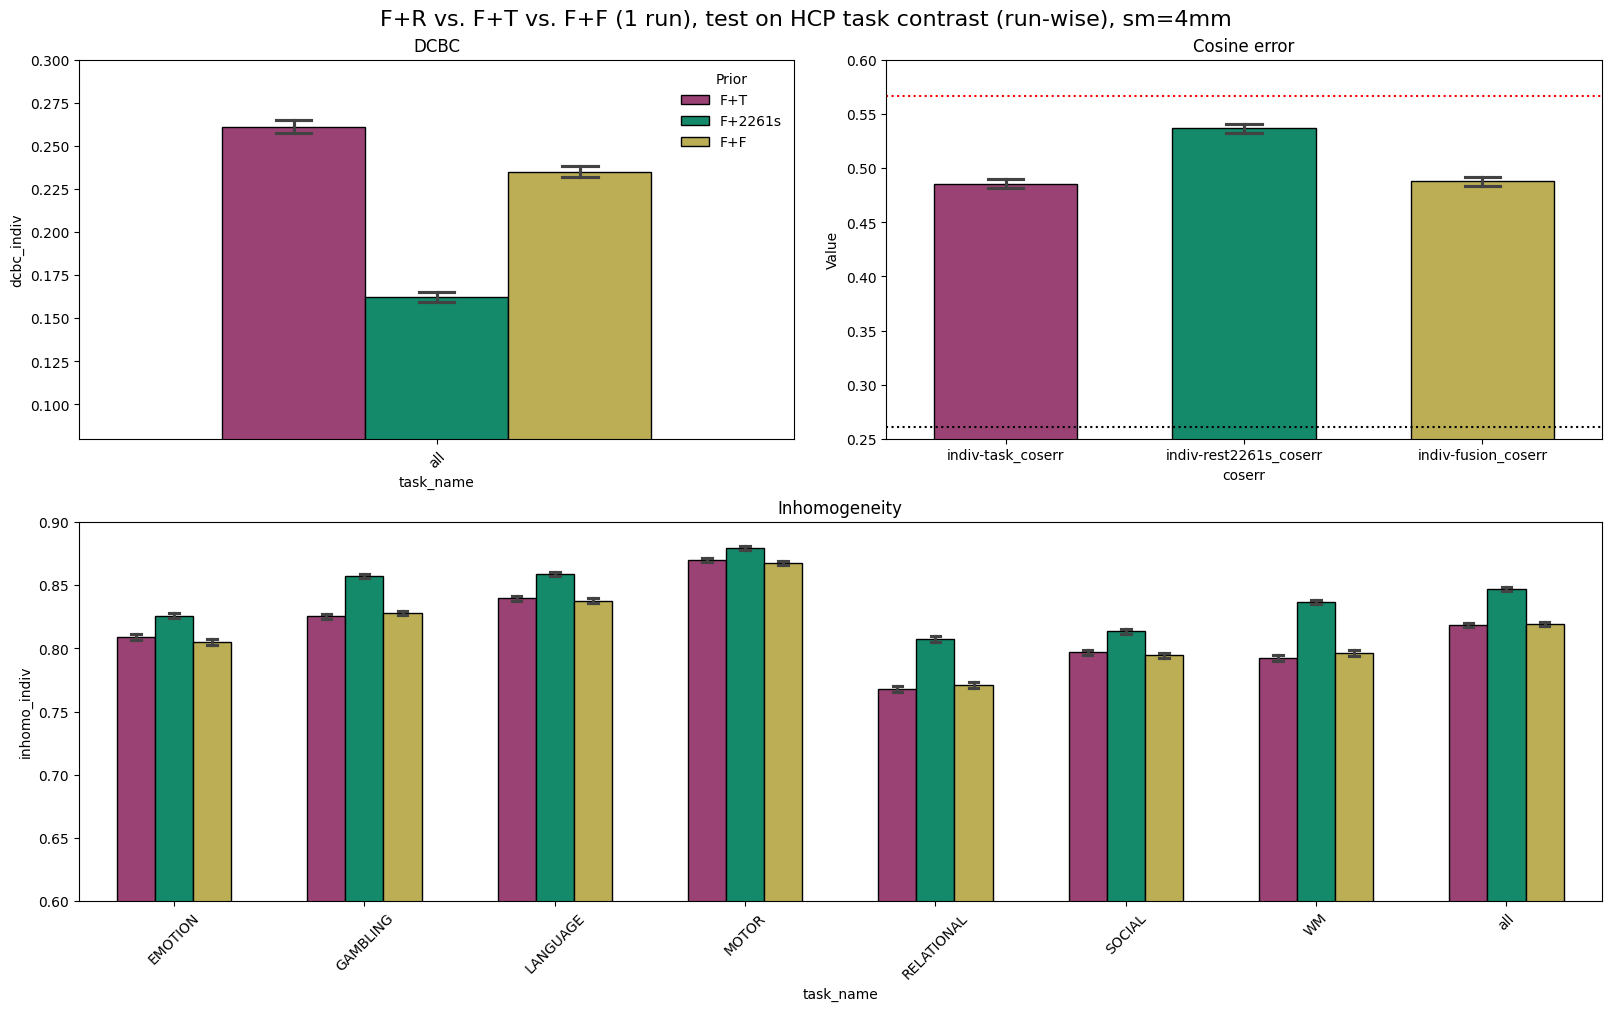

(3200,) (3200,) (1600,)
TtestResult(statistic=79.1846789812892, pvalue=2.0646343761673756e-152, df=199)
TtestResult(statistic=51.223091853051564, pvalue=1.4481397692687952e-116, df=199)
TtestResult(statistic=-51.44528171542216, pvalue=6.49939279121793e-117, df=199)
TtestResult(statistic=-40.33547605126411, pvalue=9.873791214136145e-98, df=199)
TtestResult(statistic=38.1569161773535, pvalue=1.7630780559808605e-93, df=199)


In [20]:
# ================= LOAD =================
HCP200_DIR = ERIS_DIR + "/dzhi/Indiv_par/Models/Models_03/indiv_parcellation/HCP200_test_set"

kong_indiv = pd.read_csv(
    "/home/dzhi/eris_mount/dzhi/Indiv_par/Results/section_2"
    "/eval_indiv-mRBM_MSHBM-HCP200_1-4run_K-17_test_on_HCPtask-allcontrasts-pos_sm4.tsv",
    sep="\t"
)
kong_indiv = kong_indiv.loc[kong_indiv["train_sess"]=="run-2"]
kong_indiv["type"] = "MSHBM"

df_fusion_2261s = pd.read_csv(HCP200_DIR + "/eval_indiv-mRBM_MdNiIbHc-HCP200_rest2261s_K-17_test_on_HCPtask-contrast_sm4.tsv", sep="\t")
df_fusion_2261s["type"] = "F+2261s"
df_fusion_2261s = df_fusion_2261s.loc[df_fusion_2261s["strength"]==10]

df_fusion_fusion_1run = pd.read_csv(HCP200_DIR + "/eval_indiv-mRBM_MdNiIbHc-HCP200_rest1run+task1run_K-17_test_on_HCPtask-contrast_sm4.tsv", sep="\t")
df_fusion_fusion_1run["type"] = "F+F"

df_task_1run = pd.read_csv(HCP200_DIR + "/eval_indiv-mRBM_MdNiIbHc-HCP200_task1run_K-17_test_on_HCPtask-contrast_sm4.tsv", sep="\t")
df_task_1run["type"] = "F+T"

results = pd.concat([kong_indiv,df_task_1run,df_fusion_2261s,df_fusion_fusion_1run], ignore_index=True)

# ================= SUBJECT MEANS =================
subj_avg = (
    results
    .groupby(["subj_num","task_name","type"], as_index=False)
    .mean(numeric_only=True)
)

# ================= COSERR =================
df_coserr = pd.read_csv(
    HCP200_DIR + "/coserr_indiv-mRBM_MdNiIbHc-HCP200_rest_vs_fusion_K-17_test_on_HCPtask-contrast_sm4.tsv",
    sep="\t"
)

df_long = df_coserr[['indiv-task_coserr','indiv-rest2261s_coserr','indiv-fusion_coserr']] \
            .melt(var_name="coserr", value_name="Value")

# ================= STYLING =================
type_order = ["F+T","F+2261s","F+F"]
palette = {
    "MSHBM": "#4477AA",
    "R+R": "#EE6677",
    "F+R": "#009E73",
    "F+2261s": "#009E73",
    "F+F": "#CCBB44",
    "F+T": "#AA3377"
}


# ========== styling ==========
BAR_WIDTH = 0.6          # smaller → gap between hue bars
EDGE_COLOR = "black"
EDGE_WIDTH = 1.0
CAPSIZE = 0.15

# 1. Define the spanning layout: Top row has 2 plots, Bottom row has 1 wide plot
layout = [
    ['dcbc', 'coserr'],
    ['inhomo', 'inhomo']
]

fig, axd = plt.subplot_mosaic(layout, figsize=(16, 10), constrained_layout=True)

# 2. Map the dictionary axes to a list to keep your axes[0], [1], [2] indexing
# Order: [Top Left, Top Right, Bottom Spanning]
axes = [axd['dcbc'], axd['coserr'], axd['inhomo']]

# ================= axes[0]: DCBC (Top Left) =================
sb.barplot(
    data=results.loc[results["task_name"]=="all"],
    x="task_name",
    y="dcbc_indiv",
    hue="type",
    hue_order=type_order,
    palette=palette,
    errorbar="se",
    capsize=CAPSIZE,
    width=BAR_WIDTH,
    dodge=True,
    ax=axes[0]
)

for bar in axes[0].patches:
    bar.set_edgecolor(EDGE_COLOR)
    bar.set_linewidth(EDGE_WIDTH)

axes[0].axhline(kong_indiv.loc[kong_indiv.task_name=="all"].dcbc_indiv.mean(), color="red", linestyle=":")
print(kong_indiv.loc[kong_indiv.task_name=="all"].dcbc_indiv.mean())
axes[0].set_ylim(0.08, 0.3)
axes[0].set_title("DCBC")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Prior", frameon=False)

# ================= axes[1]: Cosine error (Top Right) =================
sb.barplot(
    data=df_long,
    x="coserr",
    y="Value",
    errorbar="se",
    palette=["#AA3377", "#009E73", "#CCBB44"],
    capsize=CAPSIZE,
    width=0.6,
    ax=axes[1]
)

for bar in axes[1].patches:
    bar.set_edgecolor(EDGE_COLOR)
    bar.set_linewidth(EDGE_WIDTH)

axes[1].axhline(df_coserr.group_coserr.mean(), color="red", linestyle=":")
axes[1].axhline(df_coserr.floor_coserr.mean(), color="black", linestyle=":")
axes[1].set_ylim(0.25, 0.6)
axes[1].set_title("Cosine error")

# ================= axes[2]: Inhomogeneity (Bottom Spanning) =================
sb.barplot(
    data=results,
    x="task_name",
    y="inhomo_indiv",
    hue="type",
    hue_order=type_order,
    palette=palette,
    errorbar="se",
    capsize=CAPSIZE,
    width=BAR_WIDTH,
    dodge=True,
    ax=axes[2]
)

for bar in axes[2].patches:
    bar.set_edgecolor(EDGE_COLOR)
    bar.set_linewidth(EDGE_WIDTH)

axes[2].axhline(kong_indiv.loc[kong_indiv.task_name=="all"].inhomo_indiv.mean(), color="red", linestyle=":")
axes[2].set_ylim(0.60, 0.90)
axes[2].set_title("Inhomogeneity")
axes[2].tick_params(axis="x", rotation=45)
axes[2].legend_.remove() # Remove legend as it's already on the top plot

plt.suptitle("F+R vs. F+T vs. F+F (1 run), test on HCP task contrast (run-wise), sm=4mm", fontsize=16)
# plt.savefig(HCP200_DIR + "/HCP_rest_fusion_all.pdf")
plt.show()

from scipy import stats
print(df_fusion_2261s.inhomo_indiv.shape, df_fusion_fusion_1run.inhomo_indiv.shape, kong_indiv.inhomo_indiv.shape)
a = kong_indiv.loc[kong_indiv.task_name == "all"]
b = df_fusion_2261s.loc[df_fusion_2261s.task_name == "all"]
c = df_fusion_fusion_1run.loc[df_fusion_fusion_1run.task_name == "all"]

print(stats.ttest_rel(a.groupby(["subj_num"]).inhomo_indiv.mean(), c.groupby(["subj_num"]).inhomo_indiv.mean()))
print(stats.ttest_rel(b.groupby(["subj_num"]).inhomo_indiv.mean(), c.groupby(["subj_num"]).inhomo_indiv.mean()))
print(stats.ttest_rel(a.groupby(["subj_num"]).dcbc_indiv.mean(), c.groupby(["subj_num"]).dcbc_indiv.mean()))
print(stats.ttest_rel(b.groupby(["subj_num"]).dcbc_indiv.mean(), c.groupby(["subj_num"]).dcbc_indiv.mean()))

coserr_rest = df_coserr.groupby(["subj_num"])["indiv-rest2261s_coserr"].mean()
coserr_fusion = df_coserr.groupby(["subj_num"])["indiv-fusion_coserr"].mean()

print(stats.ttest_rel(coserr_rest, coserr_fusion))

### On the other hand, the fusion parcellation show higher reliability than pure task parcellation

within-subject Dice

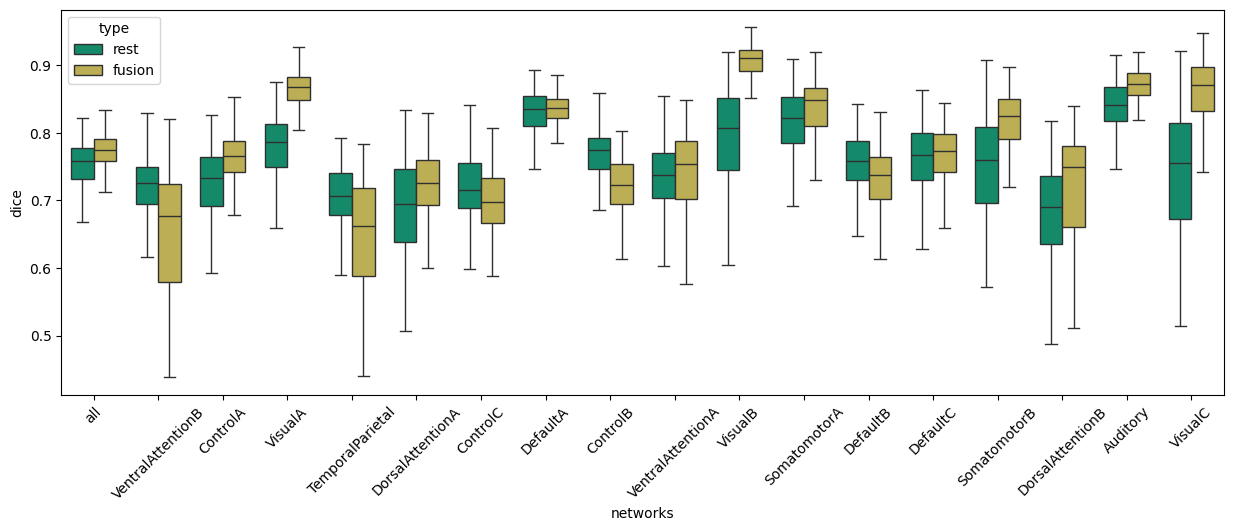

0.03262832212562735
0.022181141112762866
0.7526626500487328
0.7735278657078744


In [7]:
HCP200_DIR = ERIS_DIR + "/dzhi/Indiv_par/Models/Models_03/indiv_parcellation/HCP200_test_set"
network_names = ['VentralAttentionB', 'ControlA', 'VisualA', 'TemporalParietal', 'DorsalAttentionA', 'ControlC', 'DefaultA',
       'ControlB', 'VentralAttentionA', 'VisualB', 'SomatomotorA','DefaultB', 'DefaultC', 'SomatomotorB', 'DorsalAttentionB',
       'Auditory', 'VisualC']
mapping = dict(zip(range(1, 18), network_names))

dice_within_task = pd.read_csv(HCP200_DIR + f'/dice/dice_within_networks_indiv-mRBM_MdNiIbHc-HCP200_task1run_K-17.tsv', sep='\t')
dice_within_task['w/b'] = 'within'
dice_within_rest = pd.read_csv(HCP200_DIR + f'/dice/dice_within_networks_indiv-mRBM_MdNiIbHc-HCP200_rest1run_K-17.tsv', sep='\t')
dice_within_rest['w/b'] = 'within'
dice_within_rest2261s = pd.read_csv(HCP200_DIR + f'/dice/dice_within_networks_indiv-mRBM_MdNiIbHc-HCP200_rest2261s_K-17.tsv', sep='\t')
dice_within_rest2261s['w/b'] = 'within'
dice_within_fusion = pd.read_csv(HCP200_DIR + f'/dice/dice_within_networks_indiv-mRBM_MdNiIbHc-HCP200_rest1run+task1run_K-17_1.tsv', sep='\t')
dice_within_fusion['w/b'] = 'within'

results = pd.concat([dice_within_rest, dice_within_fusion], ignore_index=True)
results["networks"] = results["networks"].apply(
    lambda x: mapping.get(int(x), x) if str(x).isdigit() else x
)
plt.figure(figsize=(15,5))
sb.boxplot(data=results, x="networks", y='dice', hue='type', width=0.7, palette=["#009E73", "#CCBB44"], showfliers=False)
plt.xticks(rotation=45)
# plt.savefig(HCP200_DIR + '/dice/dice_hcp_within_networks.pdf', format='pdf')
plt.show()
print(dice_within_rest.loc[dice_within_rest["networks"] == "all"].dice.std())
print(dice_within_fusion.loc[dice_within_fusion["networks"] == "all"].dice.std())

print(dice_within_rest.loc[dice_within_rest["networks"] == "all"].dice.mean())
print(dice_within_fusion.loc[dice_within_fusion["networks"] == "all"].dice.mean())

between-subject Dice

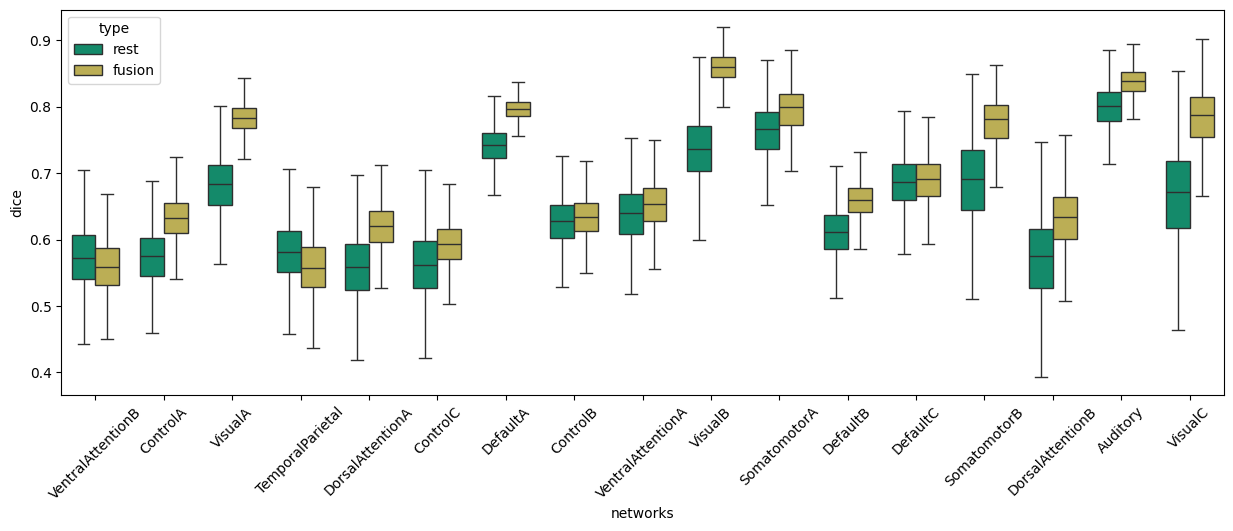

In [5]:
dice_between_task = pd.read_csv(HCP200_DIR + f'/dice/dice_between_networks_indiv-mRBM_MdNiIbHc-HCP200_task1run_K-17.tsv', sep='\t')
dice_between_task['type'] = 'task'
dice_between_task['w/b'] = 'between'
dice_between_rest = pd.read_csv(HCP200_DIR + f'/dice/dice_between_networks_indiv-mRBM_MdNiIbHc-HCP200_rest1run_K-17.tsv', sep='\t')
dice_between_rest['type'] = 'rest'
dice_between_rest['w/b'] = 'between'
dice_between_rest2261s = pd.read_csv(HCP200_DIR + f'/dice/dice_between_networks_indiv-mRBM_MdNiIbHc-HCP200_rest2261s_K-17.tsv', sep='\t')
dice_between_rest2261s['type'] = 'rest2261s'
dice_between_rest2261s['w/b'] = 'between'
dice_between_fusion = pd.read_csv(HCP200_DIR + f'/dice/dice_between_networks_indiv-mRBM_MdNiIbHc-HCP200_rest1run+task1run_K-17_1.tsv', sep='\t')
dice_between_fusion['type'] = 'fusion'
dice_between_fusion['w/b'] = 'between'

df_all = pd.DataFrame()
for df_bet in [dice_between_rest, dice_between_fusion]:
    df_long = pd.melt(df_bet, id_vars=['atlas', 'K', 'networks', 'subj', 'type', 'w/b'],  
        value_vars=[f'dice_network_{i}' for i in range(1, 18)], var_name='networks', value_name='dice')
    df_long = df_long.loc[:, ~df_long.columns.duplicated()]
    df_long['networks'] = df_long['networks'].str.extract('(\d+)').astype(int)
    df_long["networks"] = df_long["networks"].map(mapping)
    df_all = pd.concat([df_all, df_long], ignore_index=True)

plt.figure(figsize=(15,5))
sb.boxplot(data=df_all, x="networks", y='dice', hue='type', width=0.7, palette=["#009E73", "#CCBB44"], showfliers=False)
plt.xticks(rotation=45)
# plt.savefig(HCP200_DIR + '/dice/dice_hcp_between_networks.pdf', format='pdf')
plt.show()

Overall overlap comparison

0.02163842184151178
0.01405335435345853
0.6498547716835635
0.6966552765195693


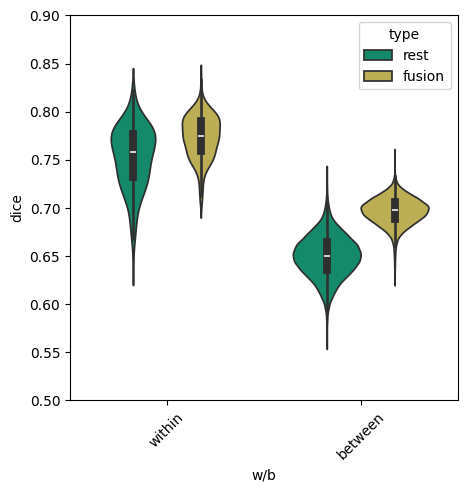

TtestResult(statistic=-9.931731997295342, pvalue=3.9014939730390663e-19, df=199)


In [6]:
results_within = results.loc[results["networks"] == "all"]

df_bet_task = pd.read_csv(HCP200_DIR + f'/dice/dice_between_indiv-mRBM_MdNiIbHc-HCP200_task1run_K-17.tsv', sep='\t')
df_bet_task['type'] = 'task'
df_bet_task['w/b'] = 'between'
df_bet_rest = pd.read_csv(HCP200_DIR + f'/dice/dice_between_indiv-mRBM_MdNiIbHc-HCP200_rest1run_K-17.tsv', sep='\t')
df_bet_rest['type'] = 'rest'
df_bet_rest['w/b'] = 'between'
df_bet_rest2261s = pd.read_csv(HCP200_DIR + f'/dice/dice_between_indiv-mRBM_MdNiIbHc-HCP200_rest2261s_K-17.tsv', sep='\t')
df_bet_rest2261s['type'] = 'rest2261s'
df_bet_rest2261s['w/b'] = 'between'
df_bet_fusion = pd.read_csv(HCP200_DIR + f'/dice/dice_between_indiv-mRBM_MdNiIbHc-HCP200_rest1run+task1run_K-17_1.tsv', sep='\t')
df_bet_fusion['type'] = 'fusion'
df_bet_fusion['w/b'] = 'between'

print(df_bet_rest.loc[df_bet_rest["networks"] == "all"].dice.std())
print(df_bet_fusion.loc[df_bet_fusion["networks"] == "all"].dice.std())

print(df_bet_rest.loc[df_bet_rest["networks"] == "all"].dice.mean())
print(df_bet_fusion.loc[df_bet_fusion["networks"] == "all"].dice.mean())

df_all = pd.concat([results_within, df_bet_rest, df_bet_fusion], ignore_index=True)
df_all = df_all.groupby(['subj', 'type', "networks", "w/b"])['dice'].mean().reset_index()

plt.figure(figsize=(5,5))
sb.violinplot(data=df_all, x="w/b", y='dice', order=["within", "between"], hue='type', 
              hue_order=["rest", "fusion"], inner='box', width=0.7, palette=["#009E73", "#CCBB44"])
# sb.boxplot(data=df_all, x="w/b", y='dice', order=["within", "between"], hue='type', 
#            hue_order=["task", "rest", "fusion"], width=0.7, showfliers=False)
plt.ylim(0.50, 0.9)
plt.xticks(rotation=45)
# plt.savefig(HCP200_DIR + '/dice/dice_hcp_all.pdf', format='pdf')
plt.show()

from scipy import stats
rest_within = df_all.loc[(df_all.type == 'rest') & (df_all["w/b"] == 'within')].groupby(["subj"])
rest_between = df_all.loc[(df_all.type == 'rest') & (df_all["w/b"] == 'between')].groupby(["subj"])
fusion_within = df_all.loc[(df_all.type == 'fusion') & (df_all["w/b"] == 'within')].groupby(["subj"])
fusion_between = df_all.loc[(df_all.type == 'fusion') & (df_all["w/b"] == 'between')].groupby(["subj"])

print(stats.ttest_rel(rest_within.dice.mean(), fusion_within.dice.mean()))

# 2. Experiments on RANDY 15 subjects dataset, K=15 networks

## Same group priors, 1run rest, or 1run rest + 1session task 
1 run rest = 15 mins, 1 session task = 23m17s, 7 x 1 run task domains.

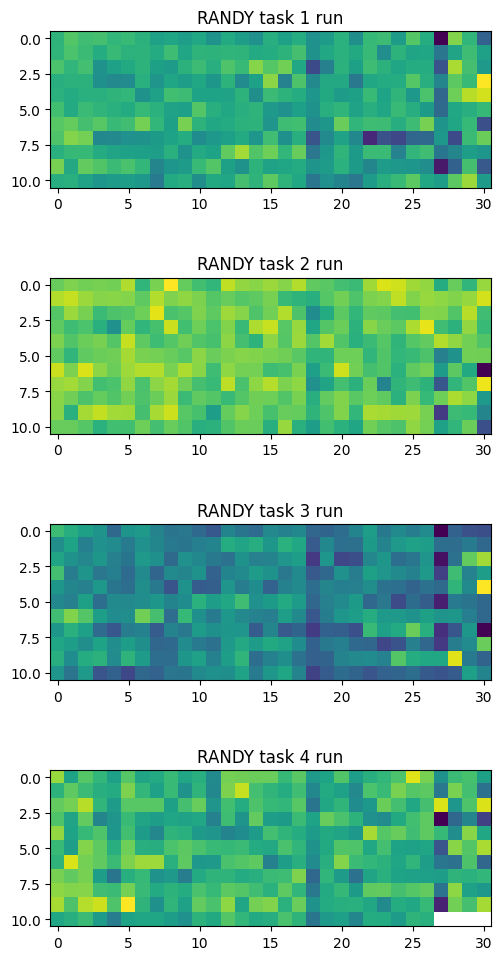

In [48]:
t_data, _, _, _, t_info = ut.build_dataset('RANDY15', atlas='fs32k', sess=['EPROJ', 'LANG', 'MOTOR', 'NBACK', 'TOM', 'VISME', 'VODDK'],
                                           cond_ind='reg_id', type='CondRun', part_ind='sn', subj=[1,2,3,5,6,7,8,11,12,13,14],
                                           part_num=np.arange(1,5), join_sess=False, join_sess_part=False, smooth=None)

plt.figure(figsize=(5,10))
plt.subplot(4,1,1)
plt.imshow(t_data[0][:,:,0])
plt.title("RANDY task 1 run")

plt.subplot(4,1,2)
plt.imshow(t_data[1][:,:,0])
plt.title("RANDY task 2 run")

plt.subplot(4,1,3)
plt.imshow(t_data[2][:,:,0])
plt.title("RANDY task 3 run")

plt.subplot(4,1,4)
plt.imshow(t_data[3][:,:,0])
plt.title("RANDY task 4 run")
plt.tight_layout()
plt.show()

# (result 4) Replication on RANDY dataset

## Rest-only prior vs. Fusion prior (using all runs resting state data)

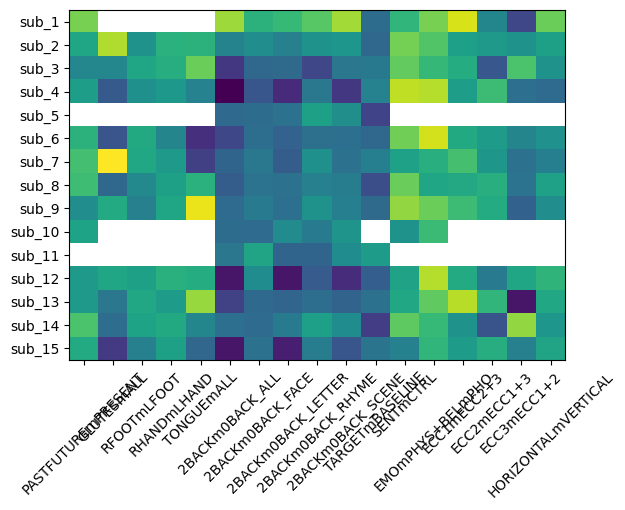

In [24]:
t_data, t_info = ut.load_randy_contrasts(space='fs32k', subj=None, hemis=None, smooth=2)
# randy_con = np.where(np.isnan(t_data[0][:,:,0]), np.nan, 1)


plt.imshow(t_data[0][:,:,0], aspect=0.8)
plt.xticks(ticks=np.arange(17), labels=t_info.contrast_name)
plt.yticks(ticks=np.arange(15), labels=[f'sub_{i}' for i in range(1,16)])

# Optional: rotate x-axis labels for readability
plt.xticks(rotation=45)
plt.show()

### Integrating individual task and rest data for parcellation better than resting state data alone

### Fusion(MdNiIbHc) prior - RANDY 2 run rs-data vs. 2run rs-data + 1session task-data (31)

(33, 23) (264, 23) (264, 23) (528, 23) (528, 23)
     subj_num task_name group_map_name     K  indiv_test_kappa  dcbc_indiv  \
14          0       all         fusion  15.0               NaN    0.288526   
15          0       all      rest3387s  15.0               NaN    0.258352   
30          1       all         fusion  15.0               NaN    0.229469   
31          1       all      rest3387s  15.0               NaN    0.212157   
46          2       all         fusion  15.0               NaN    0.232080   
47          2       all      rest3387s  15.0               NaN    0.207256   
62          3       all         fusion  15.0               NaN    0.261821   
63          3       all      rest3387s  15.0               NaN    0.263112   
78          4       all         fusion  15.0               NaN    0.313472   
79          4       all      rest3387s  15.0               NaN    0.302716   
94          5       all         fusion  15.0               NaN    0.292165   
95          5  

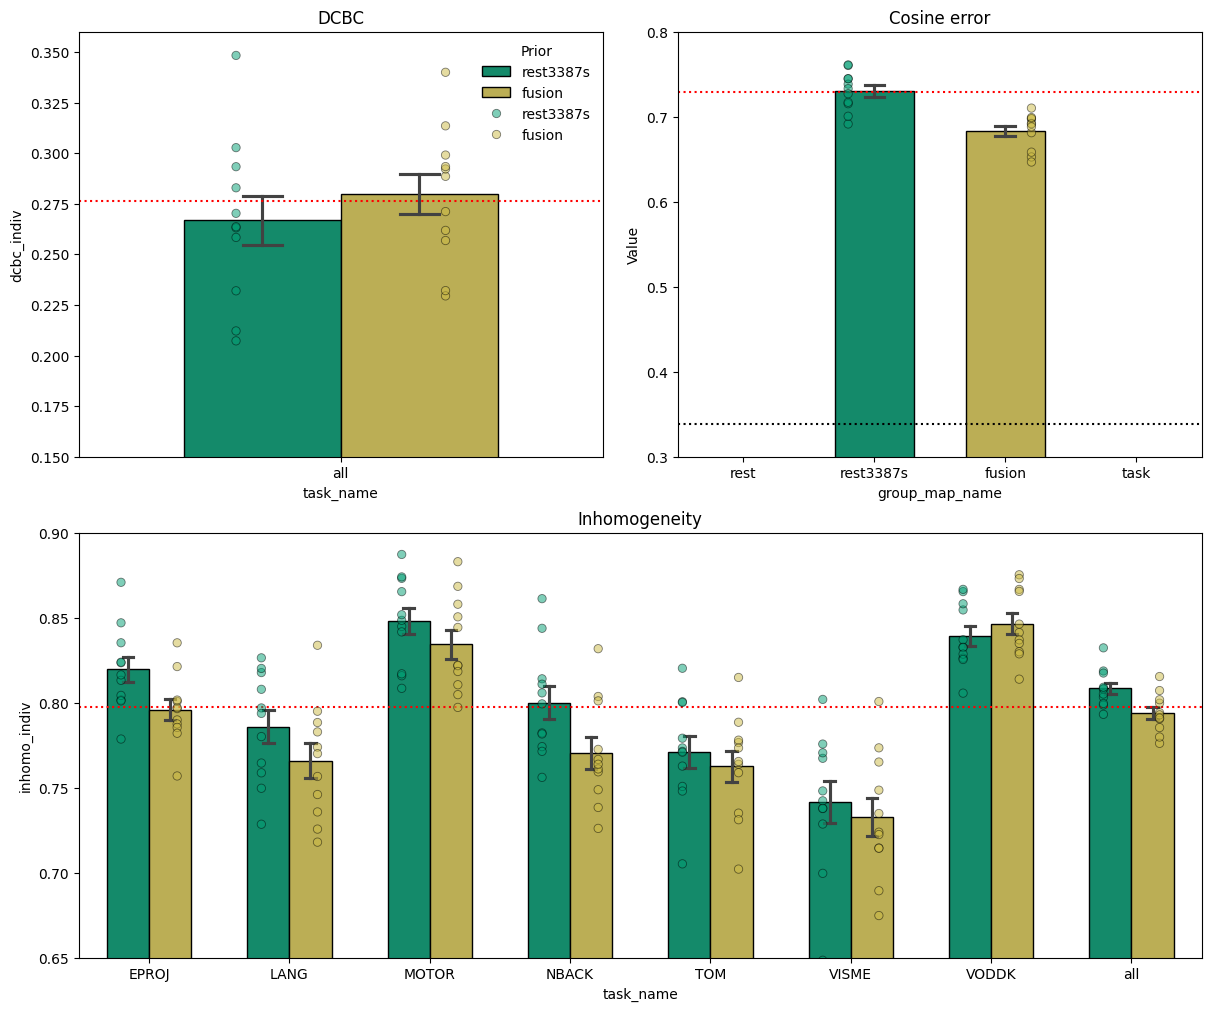

TtestResult(statistic=-3.323422046131296, pvalue=0.007702858367270985, df=10)
TtestResult(statistic=13.167871158791604, pvalue=1.2142206465204968e-07, df=10)
TtestResult(statistic=-1.3986699307610881, pvalue=0.1921524540139637, df=10)
TtestResult(statistic=1.4775764721263436, pvalue=0.17030975943901816, df=10)
TtestResult(statistic=12.475400121656186, pvalue=2.0256030814548901e-07, df=10)


In [3]:
RES_DIR = ERIS_DIR + '/dzhi/Indiv_par/Evaluations'
du15 = pd.read_csv(RES_DIR + '/eval_DU15_indiv_test_on_RANDYtask-betas_sm0_run123_11subjects.tsv', sep='\t')
du15 = du15.loc[du15["task_name"] == "all"]
df_rest = pd.read_csv(RES_DIR + '/eval_MdNiIbHc+RANDYrest-1toallrun_K-15_indiv-mRBM_test_on_RANDYtask-betas_sm0_run123_11subjects.tsv',sep='\t')
df_fusion = pd.read_csv(RES_DIR + '/eval_MdNiIbHc+RANDYrest2run+task1run_K-15_indiv-mRBM_test_on_RANDYtask-betas_sm0_run123_11subjects.tsv',sep='\t')
df_task = pd.read_csv(RES_DIR + '/eval_MdNiIbHc+RANDYtask1run_K-15_indiv-mRBM_test_on_RANDYtask-betas_sm0_run123_11subjects.tsv', sep='\t')
df_rest_3387 = pd.read_csv(RES_DIR + '/eval_MdNiIbHc+RANDYrest-3387s_K-15_indiv-mRBM_test_on_RANDYtask-contrast_sm2_11subjects.tsv', sep='\t')

df_rest = df_rest.loc[(df_rest["spatial_w"] == 0) & (df_rest["train_runs"] == '2') & (df_rest["strength"] == 1)]
df_rest['group_map_name'] = 'rest'
df_rest_3387 = df_rest_3387.loc[(df_rest_3387["strength"] == 1)]
df_rest_3387['group_map_name'] = 'rest3387s'
df_fusion = df_fusion.loc[(df_fusion["strength"] == 1)]
df_fusion['group_map_name'] = 'fusion'
df_task = df_task.loc[(df_task["strength"] == 1)]
df_task['group_map_name'] = 'task'
df_coserr = pd.read_csv(RES_DIR + f'/coserr_indiv-mRBM_MdNiIbHc-RANDY_rest2run_vs_task1run_vs_fusion_K-15_test_on_RANDYtask-beta_sm0_run123_11subjects.tsv', sep='\t')
print(du15.shape, df_rest.shape, df_rest_3387.shape, df_fusion.shape, df_task.shape)
results = pd.concat([df_rest_3387, df_fusion], ignore_index=False)

palette = {
    "rest":   "#009E73",
    "rest3387s":   "#009E73",
    "fusion": "#CCBB44",
    "task":   "#AA3377"
}

hue_order = ["rest3387s","fusion"]

coserr_palette = {
    "indiv-rest_coserr":   "#009E73",
    "indiv-rest3387s_coserr":   "#49FF91",
    "indiv-fusion_coserr": "#CCBB44",
    "indiv-task_coserr":   "#AA3377"
}
BAR_WIDTH = 0.6
EDGE_COLOR = "black"
EDGE_WIDTH = 1.0
CAPSIZE = 0.15
DOT_ALPHA = 0.5
DOT_SIZE = 6
# ---------- subject means for DCBC & Inhomogeneity ----------
subj_avg = (
    results
    .groupby(["subj_num","task_name","group_map_name"], as_index=False)
    .mean(numeric_only=True)
)
coserr_subj = (
    df_coserr
    .groupby("subj_num")
    .mean(numeric_only=True)
    .reset_index()
)
df_coserr_long = coserr_subj.melt(
    id_vars="subj_num",
    value_vars=[
        "indiv-rest_coserr",
        "indiv-rest3387s_coserr",
        "indiv-fusion_coserr",
        "indiv-task_coserr",
    ],
    var_name="coserr",
    value_name="Value"
)

df_coserr_long["group_map_name"] = df_coserr_long["coserr"].map({
    "indiv-rest_coserr": "rest",
    "indiv-rest3387s_coserr": "rest3387s",
    "indiv-fusion_coserr": "fusion",
    "indiv-task_coserr": "task",
})

# ... (Keep all your data processing and palette definitions as they are) ...

# 1. Define the spanning layout
# 'dcbc' and 'cosine' on top, 'inhomo' spanning the bottom
layout = [
    ['dcbc', 'cosine'],
    ['inhomo', 'inhomo']
]

fig, axd = plt.subplot_mosaic(layout, figsize=(12, 10), constrained_layout=True)

# 2. Map them to a list so your existing axes[0], axes[1], axes[2] indexing works
# We order them: [Top Left, Top Right, Bottom Span]
axes = [axd['dcbc'], axd['cosine'], axd['inhomo']]
print(subj_avg.loc[subj_avg["task_name"]=="all"])
# ================= axes[0]: DCBC (Top Left) =================
sb.barplot(
    data=subj_avg.loc[subj_avg["task_name"]=="all"],
    x="task_name", y="dcbc_indiv",
    hue="group_map_name", hue_order=hue_order,
    palette=palette,
    errorbar="se", capsize=CAPSIZE,
    width=BAR_WIDTH, dodge=True, ax=axes[0]
)

for b in axes[0].patches:
    b.set_edgecolor("black")
    b.set_linewidth(1)

sb.stripplot(
    data=subj_avg.loc[subj_avg["task_name"]=="all"],
    x="task_name", y="dcbc_indiv",
    hue="group_map_name", hue_order=hue_order,
    palette=palette,
    dodge=True, jitter=False,
    size=DOT_SIZE, alpha=DOT_ALPHA,
    edgecolor="black", linewidth=0.6,
    ax=axes[0]
)

axes[0].axhline(du15.dcbc_indiv.mean(), color="red", linestyle=":")
axes[0].set_ylim(0.15, 0.36)
axes[0].set_title("DCBC")
axes[0].legend(title="Prior", frameon=False)

# ================= axes[1]: Cosine Error (Top Right) =================
sb.barplot(
    data=df_coserr_long,
    x="group_map_name", y="Value",
    hue="group_map_name", hue_order=hue_order,
    palette=palette,
    errorbar="se", capsize=CAPSIZE,
    width=0.6, dodge=False, ax=axes[1]
)

for b in axes[1].patches:
    b.set_edgecolor("black")
    b.set_linewidth(1)

sb.stripplot(
    data=df_coserr_long,
    x="group_map_name", y="Value",
    hue="group_map_name", hue_order=hue_order,
    palette=palette,
    dodge=True, jitter=False,
    size=DOT_SIZE, alpha=DOT_ALPHA,
    edgecolor="black", linewidth=0.6,
    ax=axes[1]
)

axes[1].axhline(df_coserr.group_coserr.mean(), color="red", linestyle=":")
axes[1].axhline(df_coserr.floor_coserr.mean(), color="black", linestyle=":")
axes[1].set_ylim(0.3, 0.8)
axes[1].set_title("Cosine error")
# axes[1].legend_.remove() # Clean up legend if needed

# ================= axes[2]: Inhomogeneity (Bottom Spanning) =================
sb.barplot(
    data=subj_avg,
    x="task_name", y="inhomo_indiv",
    hue="group_map_name", hue_order=hue_order,
    palette=palette,
    errorbar="se", capsize=CAPSIZE,
    width=BAR_WIDTH, dodge=True, ax=axes[2]
)

for b in axes[2].patches:
    b.set_edgecolor("black")
    b.set_linewidth(1)

sb.stripplot(
    data=subj_avg,
    x="task_name", y="inhomo_indiv",
    hue="group_map_name", hue_order=hue_order,
    palette=palette,
    dodge=True, jitter=False,
    size=DOT_SIZE, alpha=DOT_ALPHA,
    edgecolor="black", linewidth=0.6,
    ax=axes[2]
)

axes[2].axhline(du15.inhomo_indiv.mean(), color="red", linestyle=":")
axes[2].set_ylim(0.65, 0.90)
axes[2].set_title("Inhomogeneity")
axes[2].get_legend().remove()

# fig.savefig(f"{RES_DIR}/randy_res5_all.pdf")
plt.show()

from scipy import stats
a = subj_avg.loc[(subj_avg.group_map_name == "rest3387s") & (subj_avg.task_name == "all")]
b = subj_avg.loc[(subj_avg.group_map_name == "fusion") & (subj_avg.task_name == "all")]

print(stats.ttest_rel(a.dcbc_indiv, b.dcbc_indiv))
print(stats.ttest_rel(a.inhomo_indiv, b.inhomo_indiv))
print(stats.ttest_rel(du15.groupby(["subj_num"]).dcbc_indiv.mean(), b.dcbc_indiv))
print(stats.ttest_rel(du15.groupby(["subj_num"]).inhomo_indiv.mean(), b.inhomo_indiv))

coserr_rest = df_coserr.groupby(["subj_num"])["indiv-rest3387s_coserr"].mean()
coserr_fusion = df_coserr.groupby(["subj_num"])["indiv-fusion_coserr"].mean()

print(stats.ttest_rel(coserr_rest, coserr_fusion))

### Dice within-subject

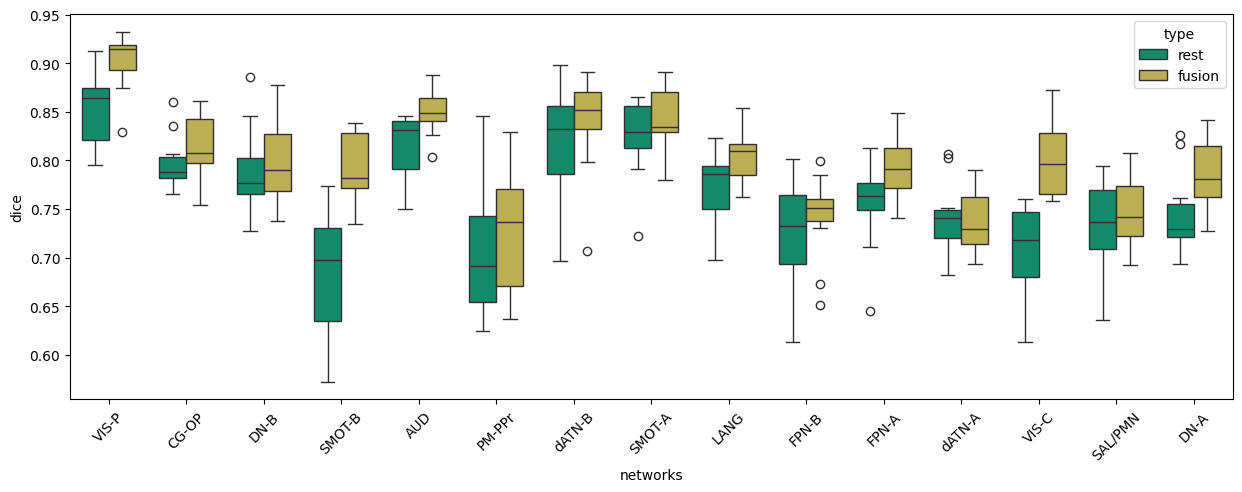

0.019426833248623647
0.01934467097873792
0.7641185034405101
0.7979144833304666


In [71]:
RES5_DIR = ERIS_DIR + '/dzhi/Indiv_par/Results/section_5'
RANDY_DIR = ERIS_DIR + "/dzhi/Indiv_par/Models/Models_03/indiv_parcellation/RANDY15_test_set"
network_names = ['VIS-P','CG-OP','DN-B','SMOT-B','AUD','PM-PPr','dATN-B','SMOT-A',
                 'LANG','FPN-B','FPN-A','dATN-A','VIS-C', 'SAL/PMN', 'DN-A']
mapping = dict(zip(range(1, 16), network_names))

dice_within_task = pd.read_csv(RES5_DIR + f'/dice_within_networks_indiv-mRBM_MdNiIbHc-RANDY_task1run_K-15.tsv', sep='\t')
dice_within_task = dice_within_task.iloc[0:176]
dice_within_task['w/b'] = 'within'
dice_within_rest = pd.read_csv(RES5_DIR + f'/dice_within_networks_indiv-mRBM_MdNiIbHc-RANDY_rest2run_K-15.tsv', sep='\t')
dice_within_rest['w/b'] = 'within'
dice_within_rest3387s = pd.read_csv(RES5_DIR + f'/dice_within_networks_indiv-mRBM_MdNiIbHc-RANDY_rest3387s_K-15.tsv', sep='\t')
dice_within_rest3387s['w/b'] = 'within'
dice_within_fusion = pd.read_csv(RES5_DIR + f'/dice_within_networks_indiv-mRBM_MdNiIbHc-RANDY_rest2run+task1run_K-15_1.tsv', sep='\t')
dice_within_fusion['w/b'] = 'within'

results = pd.concat([dice_within_rest, dice_within_fusion], ignore_index=True)
results = results.groupby(['subj', 'type', "networks"])['dice'].mean().reset_index()

results["networks"] = results["networks"].apply(
    lambda x: mapping.get(int(x), x) if str(x).isdigit() else x
)
plt.figure(figsize=(15,5))
sb.boxplot(data=results, x="networks", y='dice', hue='type', order=network_names, 
           hue_order=["rest", "fusion"], width=0.7, palette=["#009E73", "#CCBB44"])
plt.xticks(rotation=45)
plt.savefig(RANDY_DIR + '/dice/dice_randy_within_networks.pdf', format='pdf')
plt.show()

print(dice_within_rest.loc[dice_within_rest["networks"] == "all"].dice.std())
print(dice_within_fusion.loc[dice_within_fusion["networks"] == "all"].dice.std())

print(dice_within_rest.loc[dice_within_rest["networks"] == "all"].dice.mean())
print(dice_within_fusion.loc[dice_within_fusion["networks"] == "all"].dice.mean())

### Dice between-subject

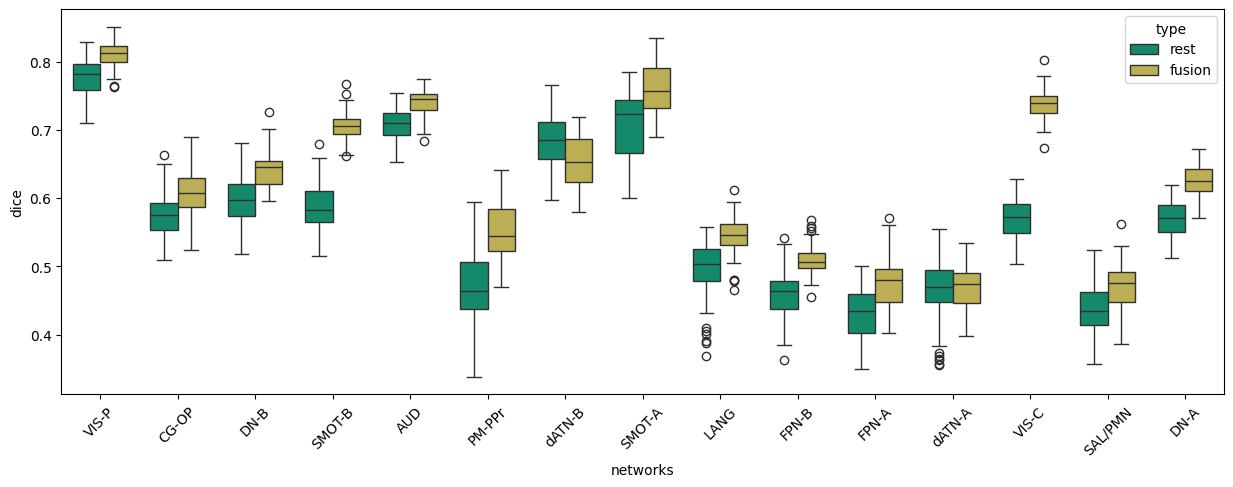

In [69]:
RES5_DIR = ERIS_DIR + '/dzhi/Indiv_par/Results/section_5'
dice_between_task = pd.read_csv(RES5_DIR + f'/dice_between_networks_indiv-mRBM_MdNiIbHc-RANDY_task1run_K-15.tsv', sep='\t')
dice_between_task['type'] = 'task'
dice_between_task['w/b'] = 'between'
dice_between_task = dice_between_task.iloc[0:55]
dice_between_rest = pd.read_csv(RES5_DIR + f'/dice_between_networks_indiv-mRBM_MdNiIbHc-RANDY_rest2run_K-15.tsv', sep='\t')
dice_between_rest['type'] = 'rest'
dice_between_rest['w/b'] = 'between'
dice_between_fusion = pd.read_csv(RES5_DIR + f'/dice_between_networks_indiv-mRBM_MdNiIbHc-RANDY_rest2run+task1run_K-15_1.tsv', sep='\t')
dice_between_fusion['type'] = 'fusion'
dice_between_fusion['w/b'] = 'between'

df_all = pd.DataFrame()
for df_bet in [dice_between_rest, dice_between_fusion]:
    df_long = pd.melt(df_bet, id_vars=['atlas', 'K', 'networks', 'subj', 'type', 'w/b'],  
        value_vars=[f'dice_network_{i}' for i in range(1, 16)], var_name='networks', value_name='dice')
    df_long = df_long.loc[:, ~df_long.columns.duplicated()]
    df_long['networks'] = df_long['networks'].str.extract('(\d+)').astype(int)
    df_long["networks"] = df_long["networks"].map(mapping)
    df_all = pd.concat([df_all, df_long], ignore_index=True)

df_all = df_all.groupby(['subj', 'type', "networks"])['dice'].mean().reset_index()
plt.figure(figsize=(15,5))
sb.boxplot(data=df_all, x="networks", order=network_names, y='dice', hue='type', hue_order=["rest", "fusion"], width=0.7, palette=["#009E73", "#CCBB44"])
plt.xticks(rotation=45)
plt.savefig(RANDY_DIR + '/dice/dice_randy_between_networks.pdf', format='pdf')
plt.show()

0.01225808202401034
0.013254479925581824
0.5687587196176702
0.6200575210831382


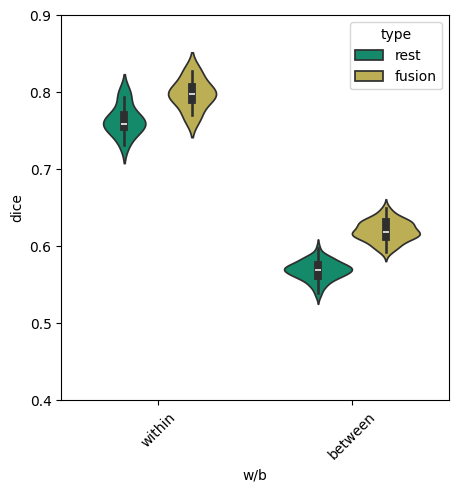

TtestResult(statistic=np.float64(-5.122516207823015), pvalue=np.float64(0.00044904110945482716), df=np.int64(10))


In [70]:
results_within = results.loc[results["networks"] == "all"]
results_within["w/b"] = "within"

df_bet_task = pd.read_csv(RES5_DIR + f'/dice_between_indiv-mRBM_MdNiIbHc-RANDY_task1run_K-15.tsv', sep='\t')
df_bet_task['type'] = 'task'
df_bet_task['w/b'] = 'between'
df_bet_task = df_bet_task.iloc[0:55]
df_bet_rest = pd.read_csv(RES5_DIR + f'/dice_between_indiv-mRBM_MdNiIbHc-RANDY_rest2run_K-15.tsv', sep='\t')
df_bet_rest['type'] = 'rest'
df_bet_rest['w/b'] = 'between'

df_bet_rest3387s = pd.read_csv(RES5_DIR + f'/dice_between_indiv-mRBM_MdNiIbHc-RANDY_rest3387s_K-15.tsv', sep='\t')
df_bet_rest3387s['type'] = 'rest3387s'
df_bet_rest3387s['w/b'] = 'between'

df_bet_fusion = pd.read_csv(RES5_DIR + f'/dice_between_indiv-mRBM_MdNiIbHc-RANDY_rest2run+task1run_K-15_1.tsv', sep='\t')
df_bet_fusion['type'] = 'fusion'
df_bet_fusion['w/b'] = 'between'

print(df_bet_rest.loc[df_bet_rest["networks"] == "all"].dice.std())
print(df_bet_fusion.loc[df_bet_fusion["networks"] == "all"].dice.std())

print(df_bet_rest.loc[df_bet_rest["networks"] == "all"].dice.mean())
print(df_bet_fusion.loc[df_bet_fusion["networks"] == "all"].dice.mean())


results_between = pd.concat([df_bet_rest, df_bet_fusion], ignore_index=True)
results_between = results_between.groupby(['subj', 'type', "networks"])['dice'].mean().reset_index()
results_between["w/b"] = "between"

df_all = pd.concat([results_within, results_between], ignore_index=True)

plt.figure(figsize=(5,5))
# sb.boxplot(data=df_all, x="w/b", y='dice', hue='type', hue_order=["task", "rest", "fusion"], width=0.7)
sb.violinplot(data=df_all, x="w/b", y='dice', order=["within", "between"], hue='type', 
              hue_order=["rest", "fusion"], inner='box', width=0.7, palette=["#009E73", "#CCBB44"])
plt.ylim(0.4, 0.9)
plt.xticks(rotation=45)
plt.savefig(RANDY_DIR + '/dice/dice_randy_all.pdf', format='pdf')
plt.show()

from scipy import stats
rest_within = df_all.loc[(df_all.type == 'rest') & (df_all["w/b"] == 'within')].groupby(["subj"])
rest_between = df_all.loc[(df_all.type == 'rest') & (df_all["w/b"] == 'between')].groupby(["subj"])
fusion_within = df_all.loc[(df_all.type == 'fusion') & (df_all["w/b"] == 'within')].groupby(["subj"])
fusion_between = df_all.loc[(df_all.type == 'fusion') & (df_all["w/b"] == 'between')].groupby(["subj"])

print(stats.ttest_rel(rest_within.dice.mean(), fusion_within.dice.mean()))

## Mean Z-values

1. EPROJ: PASTFUTUREmPRESENT (index:0), Target network: DN-A
2. MOTOR: GLUTESmALL, RFOOTmLFOOT, RHANDmLHAND, TONGUEmALL (index:1-4), Target network: SMOT-A/B
3. NBACK: 2BACKm0BACK (index:5-9), Target network: FPN-A, FPN-B
4. ODDBALL: TARGETmBASELINE (index:10), Target network: SAL/PMN, CG-OP
5. LANG: SENTmCTRL (index:11), Target network: Language
6. TOM: EMOmPHYS+BELmPHO (index:12), Target network: DN-B
7. VISUAL: ECC1mECC2+3, ECC2mECC1+3, ECC3mECC1+2, HORIZONTALmVERTICAL (index: 13-16) Target netowrk: Visual

In [3]:
def plot_zvalues(input, contrast_idx, t_info, parcel_name=None):
    # Validate input
    assert input.ndim == 3, "Input tensor must be 3D: (subjects, parcels, contrasts)"
    num_subjects, num_parcels, num_contrasts = input.shape
    assert 0 <= contrast_idx < num_contrasts, "Invalid contrast index"

    # Extract the data for the given contrast
    data = input[:, :, contrast_idx]  # shape: (num_subjects, number_parcels)

    # Create parcel labels if not provided
    if parcel_name is None:
        parcel_name = [f'Parcel {i}' for i in range(num_parcels)]
    else:
        assert len(parcel_name) == num_parcels, 'Invalid parcel names'

    # Create DataFrame for plotting
    df = pd.DataFrame()        
    for i in range(num_parcels):
        this_df = pd.DataFrame({'subject': np.arange(num_subjects),
            'parcel': parcel_name[i],
            'z_value': data[:,i],
            'domain': t_info.iloc[contrast_idx].task_name
        })
        df = pd.concat([df, this_df], ignore_index=True)

    df['contrast_name'] = t_info.iloc[contrast_idx].contrast_name

    return df

In [8]:
randy_tasks = ['EPROJ', 'LANG', 'MOTOR', 'NBACK', 'TOM', 'VISME', 'VODDK']
randy_good_subjlist = [1,2,3,5,6,7,8,11,12,13,14]
randy_bad_subjlist = [0,4,9,10]
t_data, _, _, _, t_info = ut.build_dataset('RANDY15', atlas='fs32k',
                                                sess=randy_tasks, cond_ind='reg_id',
                                                type='CondRun', part_ind='sn', subj=randy_good_subjlist,
                                                part_num=np.arange(1,4), join_sess=False,
                                                join_sess_part=False, smooth=None)
t_info = t_info[0]

In [5]:
d_type = ['rest', 'fusion']
randy_good_subjlist = [1,2,3,5,6,7,8,11,12,13,14]
train_run = [1,2,3]

du_15 = np.load(f'{ERIS_DIR}/dzhi/Indiv_par/Models/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
                   f'/zvalue_DU-indiv_K-15.npy')[randy_good_subjlist]

res1, res2, res3 = [], [], []
for p in [1]:
    for r in train_run:
        test_run = train_run.copy()
        test_run.remove(r)
        for tr in test_run:
            res1.append(np.load(f'{ERIS_DIR}/dzhi/Indiv_par/Models/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
              f'/zvalue_indiv_asym_MdNiIbHc+RANDYrest2run+task1run{r}-indiv_K-15_strengh-{p}_spatial-0_betas-run{tr}_sm0_11sub.npy'))


# convert lists to arrays
res1 = np.stack(res1, axis=0)

# average across the first dimension (different p values)
res1 = np.mean(res1, axis=0)

# res1 = np.load(f'/data/tge/dzhi/Indiv_par/Models/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
#               '/zvalue_indiv_asym_MSHBM40+RANDYrest-1run-indiv_K-15_strengh-1_spatial-1_sm2.npy')
# res2 = np.load('/data/tge/dzhi/Indiv_par/Models/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
#                   f'/zvalue_indiv_asym_HBPHc+RANDYrest-1run-indiv_K-15_strengh-2_spatial-0_sm2.npy')
# res3 = np.load('/data/tge/dzhi/Indiv_par/Models/Models_03/indiv_parcellation/RANDY15_test_set/zvalues' +
#               f'/zvalue_indiv_asym_MdNiIbHc+RANDYrest-1run-indiv_K-15_strengh-2_spatial-0_sm2.npy')

print(res2.shape, res3.shape)
df_all = pd.DataFrame()
for j, res in enumerate([res1]):
    for i in [0,10,11,12,5,6,7,8,9]:
        df = plot_zvalues(res, i, t_info, parcel_name=net_name[1:])
        df['dtype'] = d_type[j]
        df_all = pd.concat([df_all, df], ignore_index=True)

con_nam = df_all['contrast_name'].unique()
plt.figure(figsize=(10, 5 * len(con_nam)))

# df_all = df_all.loc[(df_all["parcel"]=="DN-A") | (df_all["parcel"]=="DN-B") | (df_all["parcel"]=="LANG")]
for n, c_name in enumerate(con_nam):
    this_df_all = df_all.loc[df_all['contrast_name']==c_name]
    domain = this_df_all['domain'].unique()
    
    plt.subplot(len(con_nam),1,n+1)
    sb.barplot(data=this_df_all, x='parcel', y='z_value', hue='dtype', errorbar='se', width=0.7)
    plt.xticks(rotation=45)
    plt.title(f'{domain}: {c_name}')


plt.tight_layout()
# plt.savefig(RES_DIR + "/z_value.pdf", format='pdf')
plt.show()

(11, 15, 17) (11, 15, 17)


NameError: name 't_info' is not defined